In [13]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os

In [14]:
folder = r'Y:\TESTDATA\DP\2026\06'
tss_files = {
    'Tek20260608T145828.tss': 'DIODE',
    'Tek20260612T135428.tss': 'CASCODE',
    'Tek20260615T120001.tss': 'CS',
}
title = 'Pattern 1 comparison'
time_range = [-3000, 3000]  # in ns
selected_channels = ['Vd', 'Vsub']  # Example channel labels to plot

In [15]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [16]:
# This part is to check all available channel labels in the TSS files
labels_dicts = []
for tss_file in tss_files.keys():
    path = find_file(tss_file, folder)
    tss = TSSFile(path, tss_file, source='Local')
    channel_labels = tss.channel_labels
    new_dict = {value: key for key, value in channel_labels.items()}
    labels_dicts.append(new_dict)

all_keys = set().union(*labels_dicts)
print('all available channel labels:', all_keys)

all available channel labels: {'VGI_S1', 'Vgi', 'Vd', 'Vg', 'VGO_HS', 'Ig', 'VGO_S2', 'VDD6_S1', 'Vsub', 'Is', 'VGO_S1'}


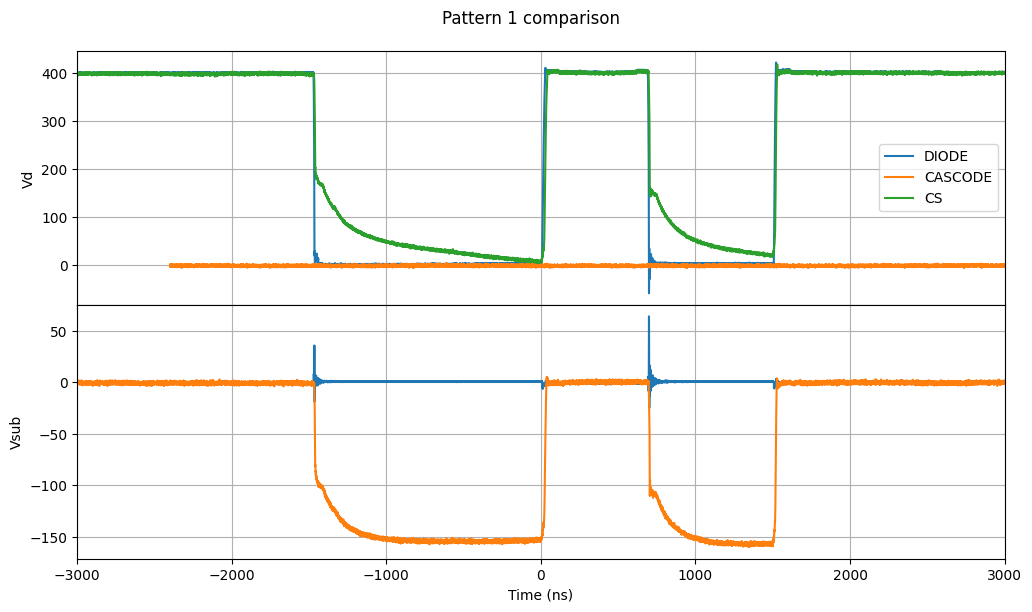

In [17]:
channels_dict = {item: index for index, item in enumerate(selected_channels)}
fig, axs = plt.subplots(len(channels_dict), 1, sharex=True, figsize=(10, len(channels_dict)*3))
fig.suptitle(title)
fig.tight_layout()
fig.subplots_adjust(hspace=0)
for tss_file, channel_labels in zip(tss_files, labels_dicts):
    path = find_file(tss_file, folder)
    tss = TSSFile(path, tss_file, source='Local')
    channel_labels = tss.channel_labels
    time = tss.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9
    for channel, label in channel_labels.items():
        if label in selected_channels:
            index = channels_dict[label]
            values = tss.waveforms[channel].values_for_frame(0)
            axs[index].plot(time, values, label=f'{tss_files[tss_file]}')
            axs[index].set_ylabel(label)
            axs[index].grid(True)

axs[0].legend()
plt.xlabel('Time (ns)')
plt.xlim(time_range)
#plt.legend(loc='best')
plt.show()